In [ ]:
import os
import glob
import numpy as np
import torch
import h5py
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    
class PlantHSIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.filepaths = []
        self.labels = []
        
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                files = glob.glob(os.path.join(cls_dir, "*.mat"))
                self.filepaths.extend(files)
                self.labels.extend([self.class_to_idx[cls_name]] * len(files))

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        
        # 1. Load the v7.3 .mat file using h5py
        hsi_cube = None
        with h5py.File(filepath, 'r') as f:
            # Search for the 3D array in the HDF5 file
            for key in f.keys():
                # Ignore reference objects and metadata
                if isinstance(f[key], h5py.Dataset):
                    data = f[key]
                    if len(data.shape) == 3:
                        # Load data into memory as a numpy array
                        hsi_cube = np.array(data)
                        break
                        
        if hsi_cube is None:
            raise ValueError(f"Could not find a valid 3D HSI array in {filepath}")
            
        # 2. Fix the MATLAB HDF5 Transpose Issue
        # MATLAB (H, W, C) becomes HDF5 (C, W, H). 
        # We need to swap the axes back to (H, W, C) so our masking logic works.
        if hsi_cube.shape[0] == 31: # 31 is the number of channels
            hsi_cube = hsi_cube.transpose(2, 1, 0)
            
        hsi_cube = hsi_cube.astype(np.float32)

        # 3. Dynamic Background Masking
        # Shape is now (H, W, 31) where Band 30 is 700nm and Band 28 is 680nm
        band_700 = hsi_cube[:, :, 30]
        band_680 = hsi_cube[:, :, 28]
        
        epsilon = 1e-8
        vegetation_index = (band_700 - band_680) / (band_700 + band_680 + epsilon)
        mask = (vegetation_index > 0.15).astype(np.float32)
        
        # Apply mask
        hsi_cube = hsi_cube * mask[:, :, np.newaxis]

        # 4. Convert to PyTorch Tensor format (C, H, W)
        tensor_cube = torch.from_numpy(hsi_cube.transpose((2, 0, 1)))

        # 5. Apply transforms
        if self.transform:
            tensor_cube = self.transform(tensor_cube)

        return tensor_cube, self.labels[idx]

Using device: cuda
GPU Name: NVIDIA H100 NVL


In [2]:
import torch.nn as nn
import torch.nn.functional as F

class SpectralAttention(nn.Module):
    def __init__(self, num_bands=31, reduction=4):
        super(SpectralAttention, self).__init__()
        # Squeeze the spatial dimensions to 1x1, looking only at the 31 bands
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        
        # Excitation: Learn the relationship between different bands
        self.fc = nn.Sequential(
            nn.Linear(num_bands, num_bands // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(num_bands // reduction, num_bands, bias=False),
            nn.Sigmoid() # Outputs a score between 0 and 1 for each band
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        
        # Squeeze
        y = self.avg_pool(x).view(b, c)
        
        # Excite
        y = self.fc(y).view(b, c, 1, 1)
        
        # Multiply the original HSI cube by the learned band weights
        return x * y.expand_as(x)

In [3]:
from torchvision import models
DIR = "/home/ai21ag3ai05/nas2/planthsidataset"
BATCH_SIZE = 512 
IMG_SIZE = (224, 224)  # Resize to a standard size for the model
NUM_CLASSES = 8

class HSI_EfficientNet(nn.Module):
    def __init__(self, num_bands=31, num_classes=8):
        super(HSI_EfficientNet, self).__init__()
        
        # 1. Our learned band importance module
        self.spectral_attention = SpectralAttention(num_bands=num_bands)
        
        # 2. Base EfficientNet
        self.backbone = models.efficientnet_b0(weights=None, num_classes=num_classes)
        
        # 3. Modify the first convolutional layer from 3 channels to 31 channels
        old_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=num_bands, 
            out_channels=old_conv.out_channels, 
            kernel_size=old_conv.kernel_size, 
            stride=old_conv.stride, 
            padding=old_conv.padding, 
            bias=False
        )

    def forward(self, x):
        # First, apply attention to figure out which bands matter most
        x = self.spectral_attention(x)
        # Then, pass the weighted datacube into EfficientNet
        x = self.backbone(x)
        return x

# Instantiate the model
model = HSI_EfficientNet(num_bands=31, num_classes=NUM_CLASSES)
model = model.to(device)

print(f"Model modified for 31-channel HSI with Band Attention.")

Model modified for 31-channel HSI with Band Attention.


In [ ]:
# 1. Define Augmentations
train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE, antialias=True),
    transforms.RandomAffine(
        degrees=20, 
        translate=(0.2, 0.2), 
        scale=(0.8, 1.2)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
])

test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE, antialias=True),
])

# 2. Load the base custom dataset
print("Mapping dataset directory...")
base_dataset = PlantHSIDataset(DIR, transform=None) # We'll apply transforms after subsetting
NUM_CLASSES = len(base_dataset.classes)
print(f"Found {NUM_CLASSES} classes.")

# 3. Create Splits
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

targets = base_dataset.labels
train_idx, temp_idx = train_test_split(
    range(len(targets)), test_size=0.2, stratify=targets, random_state=42
)

temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_targets, random_state=42
)

# 4. Apply specific transforms via a small wrapper class to Subsets
class TransformWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

train_data = TransformWrapper(Subset(base_dataset, train_idx), train_transforms)
val_data = TransformWrapper(Subset(base_dataset, val_idx), test_transforms)
test_data = TransformWrapper(Subset(base_dataset, test_idx), test_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=16, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=16, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=16, pin_memory=True)

Mapping dataset directory...
Found 8 classes.


In [ ]:
import os
import json
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# --- CONFIGURATION ---
EPOCHS = 100
LEARNING_RATE = 1e-4 
PATIENCE = 10

# --- PATHS ---
MODEL_SAVE_PATH = "best_plant_hsi_disease.pth"
HISTORY_SAVE_PATH = "training_hsi_history.json"
CHECKPOINT_DIR = "model_hsi_checkpoints"

# We use this specific file to seamlessly resume if interrupted
LATEST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "latest_state_checkpoint.pth")

# Create the checkpoints folder if it doesn't exist
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler('cuda')

start_epoch = 0
best_val_loss = float('inf')
patience_counter = 0
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

# 1. Load History (if it exists)
if os.path.exists(HISTORY_SAVE_PATH):
    print(f"Loading training history from {HISTORY_SAVE_PATH}...")
    with open(HISTORY_SAVE_PATH, 'r') as f:
        history = json.load(f)

# 2. Load Latest Training State (Model, Optimizer, Epoch)
if os.path.exists(LATEST_CHECKPOINT_PATH):
    print(f"Found interrupt checkpoint! Resuming from {LATEST_CHECKPOINT_PATH}...")
    checkpoint = torch.load(LATEST_CHECKPOINT_PATH, weights_only=False) 
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    patience_counter = checkpoint.get('patience_counter', 0)
    
    print(f"Successfully restored state. Resuming at Epoch {start_epoch + 1}.")
else:
    print("No interrupt checkpoint found. Starting fresh from Epoch 1.")

best_model_weights = copy.deepcopy(model.state_dict())

# --- TRAINING LOOP ---
if start_epoch >= EPOCHS:
    print(f"Model has already trained for {start_epoch} epochs (Target: {EPOCHS}).")
else:
    print("\nStarting Training Loop...")
    
    for epoch in range(start_epoch, EPOCHS):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, running_corrects, total_samples = 0.0, 0, 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
        
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad() 
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)
            
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")
            
        epoch_loss = running_loss / total_samples
        epoch_acc = (running_corrects.double() / total_samples).item()
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_corrects, val_samples = 0.0, 0, 0
        
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                val_samples += inputs.size(0)
                
                val_pbar.set_postfix(loss=f"{loss.item():.4f}")
                
        epoch_val_loss = val_loss / val_samples
        epoch_val_acc = (val_corrects.double() / val_samples).item()
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        # 1. Update the JSON file immediately so it is never lost
        with open(HISTORY_SAVE_PATH, 'w') as f:
            json.dump(history, f, indent=4)
            
        # 2. Check for Best Model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
            
            # Save the absolute best weights
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"--> Validation loss improved! Best model saved to {MODEL_SAVE_PATH}")
        else:
            patience_counter += 1

        # 3. Save the Latest State Checkpoint
        checkpoint_state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter
        }
        torch.save(checkpoint_state, LATEST_CHECKPOINT_PATH)
        
        # 4. Save an interval checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            interval_filename = f"checkpoint_epoch_{epoch+1}.pth"
            interval_path = os.path.join(CHECKPOINT_DIR, interval_filename)
            torch.save(model.state_dict(), interval_path)
            print(f"--> Saved 5-epoch interval checkpoint: {interval_path}")

        # 5. Early Stopping
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

    # --- POST-TRAINING TASKS ---
    model.load_state_dict(best_model_weights)
    print("\nTraining Complete. Best validation weights restored to active model.")

Loading training history from training_hsi_history.json...
Found interrupt checkpoint! Resuming from model_hsi_checkpoints/latest_state_checkpoint.pth...
Successfully restored state. Resuming at Epoch 63.

Starting Training Loop...


Epoch 63/100 | Train Loss: 0.4429 Acc: 0.8436 | Val Loss: 0.4592 Acc: 0.8549


Epoch 64/100 | Train Loss: 0.4390 Acc: 0.8440 | Val Loss: 0.3766 Acc: 0.8681
--> Validation loss improved! Best model saved to best_plant_hsi_disease.pth


Epoch 65/100 | Train Loss: 0.4535 Acc: 0.8445 | Val Loss: 0.5014 Acc: 0.8462
--> Saved 5-epoch interval checkpoint: model_hsi_checkpoints/checkpoint_epoch_65.pth


Epoch 66/100 | Train Loss: 0.4261 Acc: 0.8527 | Val Loss: 0.3934 Acc: 0.8714


...

Epoch 91/100 | Train Loss: 0.2570 Acc: 0.9096 | Val Loss: 0.3569 Acc: 0.8868


Epoch 92/100 | Train Loss: 0.2600 Acc: 0.9099 | Val Loss: 0.3323 Acc: 0.8835


Epoch 93/100 | Train Loss: 0.2756 Acc: 0.9055 | Val Loss: 0.3254 Acc: 0.8923


Epoch 94/100 | Train Loss: 0.2443 Acc: 0.9144 | Val Loss: 0.3031 Acc: 0.9066


Epoch 95/100 | Train Loss: 0.2551 Acc: 0.9133 | Val Loss: 0.2708 Acc: 0.9066
--> Saved 5-epoch interval checkpoint: model_hsi_checkpoints/checkpoint_epoch_95.pth

Early stopping triggered at epoch 95

Training Complete. Best validation weights restored to active model.


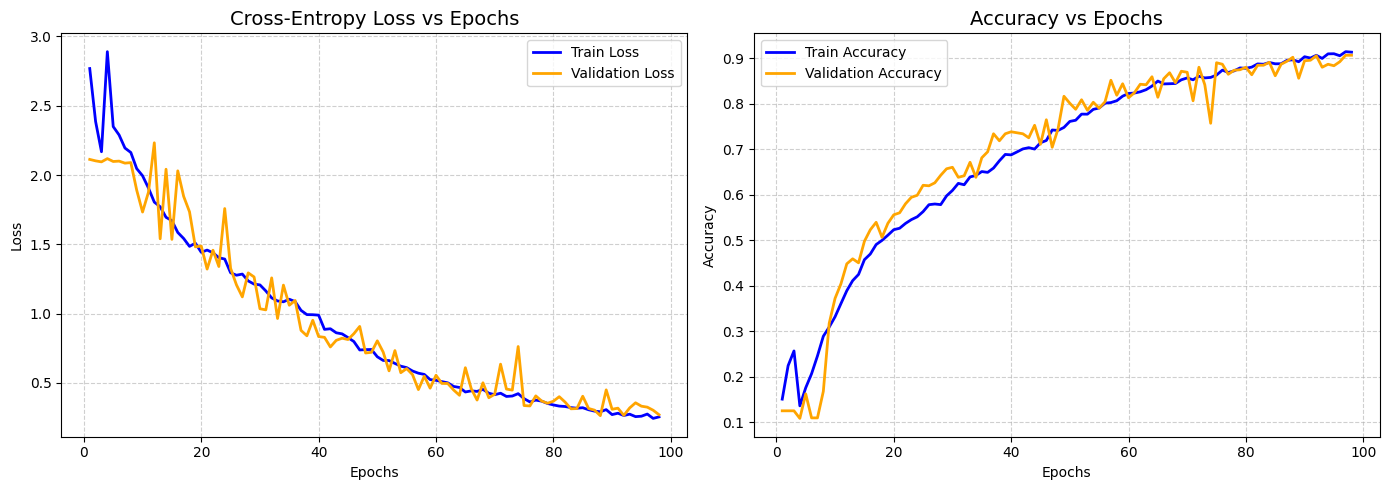

In [6]:
import json
import matplotlib.pyplot as plt

HISTORY_SAVE_PATH = "training_hsi_history.json"

# Load the tracked history
with open(HISTORY_SAVE_PATH, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['loss']) + 1)

# Set up the plot
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(epochs, history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Cross-Entropy Loss vs Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Accuracy vs Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()

Loading best weights from best_plant_hsi_disease.pth...
Generating predictions on the Test Set...


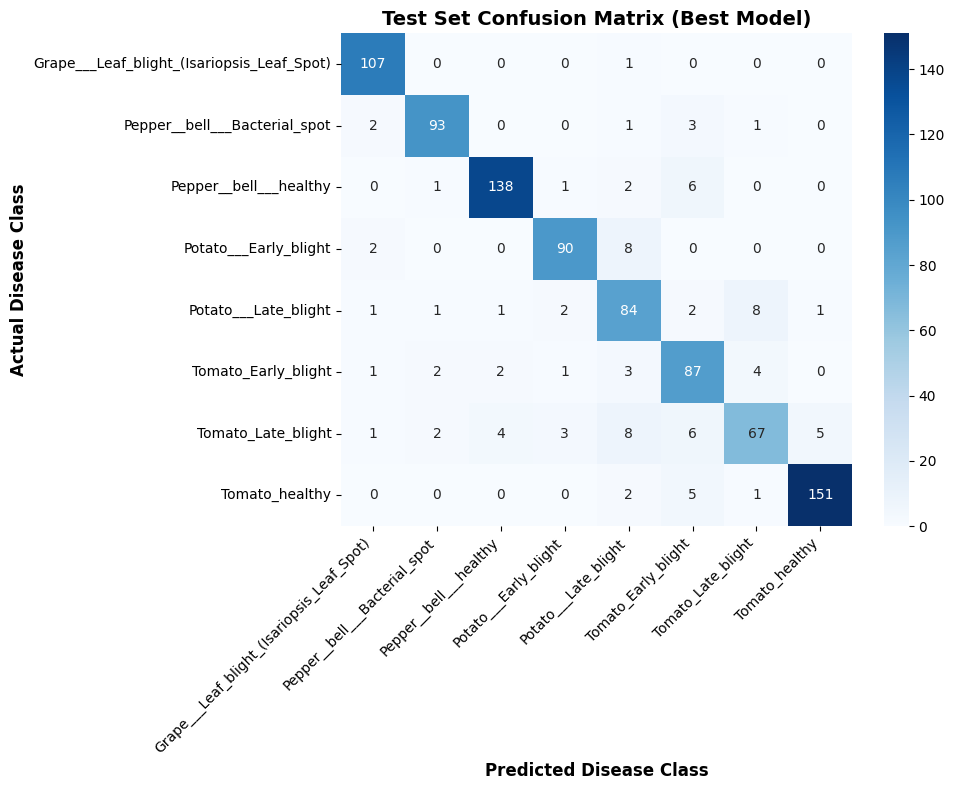

In [7]:
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. DEFINE THE BLUEPRINT TO LOAD WEIGHTS
# ==========================================
class SpectralAttention(nn.Module):
    def __init__(self, num_bands=31, reduction=4):
        super(SpectralAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(num_bands, num_bands // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(num_bands // reduction, num_bands, bias=False),
            nn.Sigmoid() 
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class HSI_EfficientNet(nn.Module):
    def __init__(self, num_bands=31, num_classes=8):
        super(HSI_EfficientNet, self).__init__()
        self.spectral_attention = SpectralAttention(num_bands=num_bands)
        self.backbone = models.efficientnet_b0(weights=None, num_classes=num_classes)
        
        old_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=num_bands, out_channels=old_conv.out_channels, 
            kernel_size=old_conv.kernel_size, stride=old_conv.stride, 
            padding=old_conv.padding, bias=False
        )

    def forward(self, x):
        x = self.spectral_attention(x)
        x = self.backbone(x)
        return x

# ==========================================
# 2. INSTANTIATE AND LOAD THE BEST MODEL
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 8
NUM_BANDS = 31

# Build the empty model
model = HSI_EfficientNet(num_bands=NUM_BANDS, num_classes=NUM_CLASSES)

# Load the weights from your best epoch
MODEL_SAVE_PATH = "best_plant_hsi_disease.pth"
print(f"Loading best weights from {MODEL_SAVE_PATH}...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))

# Send to GPU and lock in evaluation mode (critical so layers like Dropout turn off)
model = model.to(device)
model.eval()

# ==========================================
# 3. GENERATE THE CONFUSION MATRIX
# ==========================================
all_preds = []
all_labels = []

print("Generating predictions on the Test Set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=base_dataset.classes, 
            yticklabels=base_dataset.classes)
plt.xlabel('Predicted Disease Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Disease Class', fontsize=12, fontweight='bold')
plt.title('Test Set Confusion Matrix (Best Model)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save and show
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("\n" + "="*50)
print("              CLASSIFICATION REPORT")
print("="*50)

# Generate the tabular report
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=base_dataset.classes, 
    digits=4 # 4 decimal places for precision
)

print(report)

with open("classification_report.txt", "w") as f:
    f.write("Test Set Classification Report\n")
    f.write("="*50 + "\n")
    f.write(report)
print("\nReport successfully saved to classification_report.txt")


              CLASSIFICATION REPORT
                                            precision    recall  f1-score   support

Grape___Leaf_blight_(Isariopsis_Leaf_Spot)     0.9386    0.9907    0.9640       108
             Pepper__bell___Bacterial_spot     0.9394    0.9300    0.9347       100
                    Pepper__bell___healthy     0.9517    0.9324    0.9420       148
                     Potato___Early_blight     0.9278    0.9000    0.9137       100
                      Potato___Late_blight     0.7706    0.8400    0.8038       100
                       Tomato_Early_blight     0.7982    0.8700    0.8325       100
                        Tomato_Late_blight     0.8272    0.6979    0.7571        96
                            Tomato_healthy     0.9618    0.9497    0.9557       159

                                  accuracy                         0.8968       911
                                 macro avg     0.8894    0.8888    0.8879       911
                              weighte

Loading model weights from best_plant_hsi_disease.pth...
Saved hsi_explainability_mat_results.png!


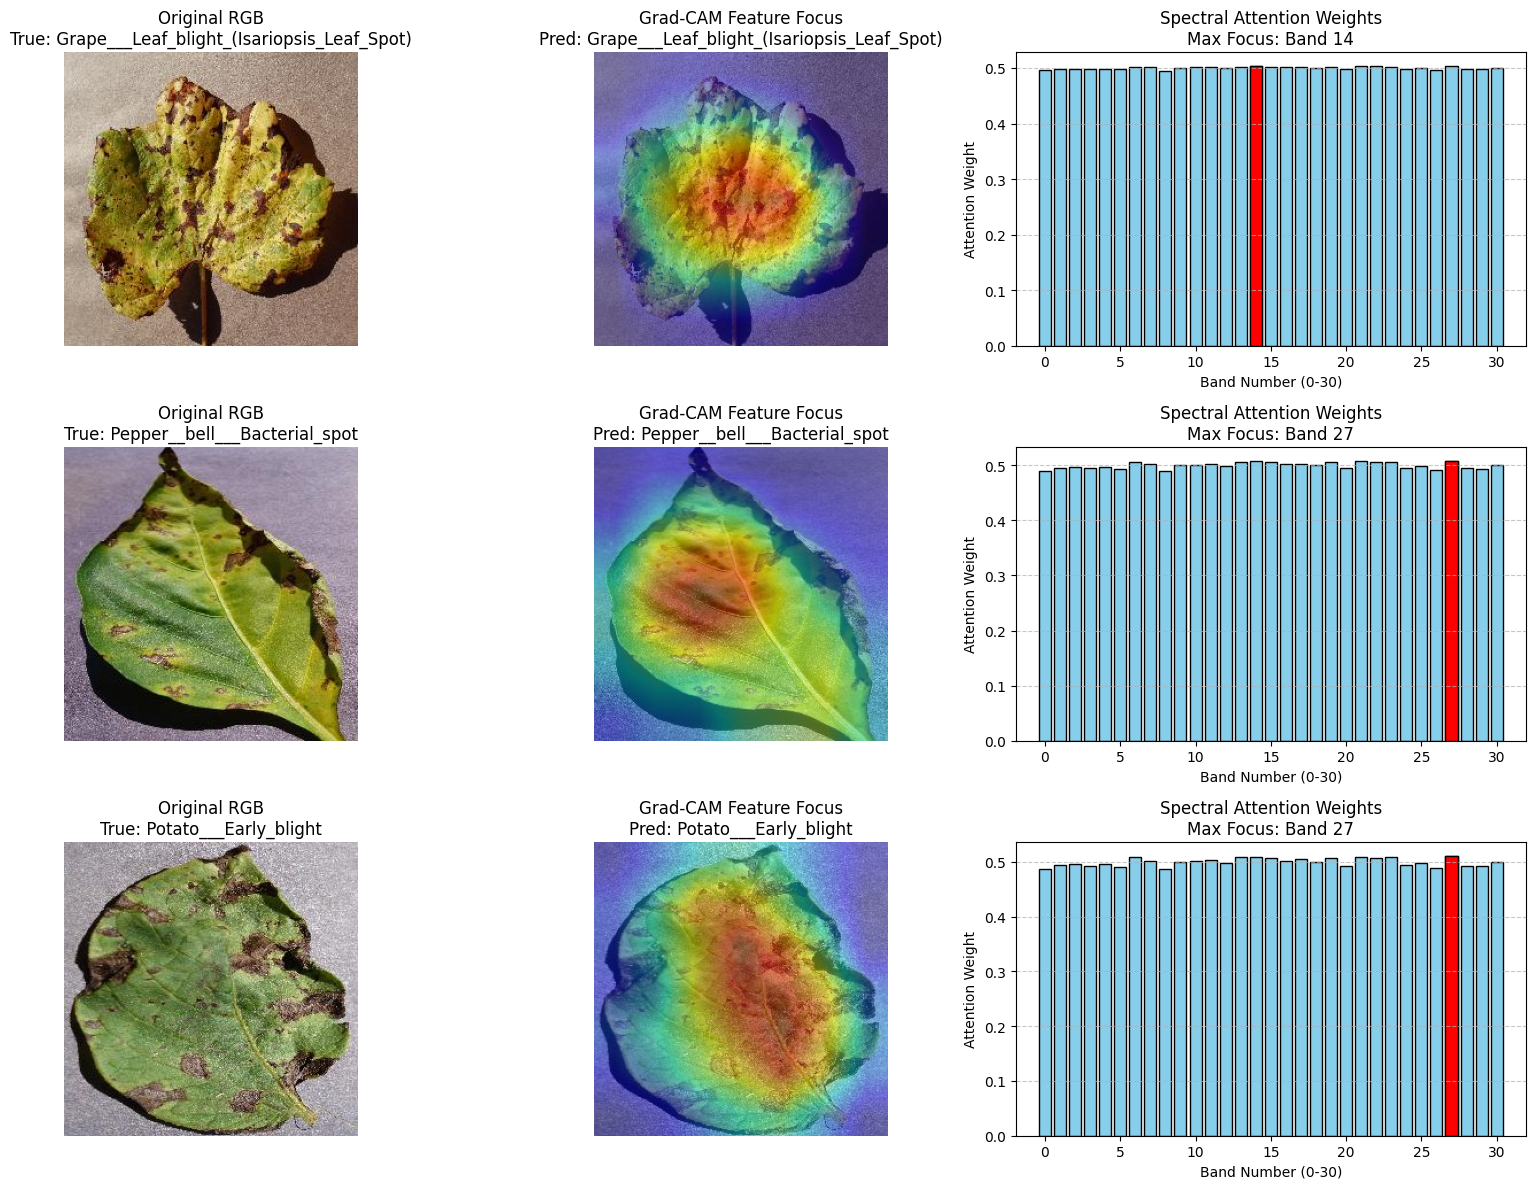

In [ ]:
import os
import glob
import cv2
import h5py
import torch
import numpy as np
import torch.nn as nn
from torchvision import models
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

# ==========================================
# 1. DIRECTORIES & CONFIGURATION
# ==========================================
# Directory containing your original .mat HSI cubes
HSI_MAT_DIR = "/home/ai21ag3ai05/nas2/planthsidataset" 
# Directory containing your actual high-res RGB images
RGB_DIR = "/home/ai21ag3ai05/nas2/plantdataset"       
MODEL_SAVE_PATH = "best_plant_hsi_disease.pth"

NUM_CLASSES = 8
NUM_BANDS = 31
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. MODEL BLUEPRINT
# ==========================================
class SpectralAttention(nn.Module):
    def __init__(self, num_bands=31, reduction=4):
        super(SpectralAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(num_bands, num_bands // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(num_bands // reduction, num_bands, bias=False),
            nn.Sigmoid() 
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class HSI_EfficientNet(nn.Module):
    def __init__(self, num_bands=31, num_classes=8):
        super(HSI_EfficientNet, self).__init__()
        self.spectral_attention = SpectralAttention(num_bands=num_bands)
        self.backbone = models.efficientnet_b0(weights=None, num_classes=num_classes)
        
        old_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=num_bands, out_channels=old_conv.out_channels, 
            kernel_size=old_conv.kernel_size, stride=old_conv.stride, 
            padding=old_conv.padding, bias=False
        )

    def forward(self, x):
        x = self.spectral_attention(x)
        x = self.backbone(x)
        return x

# Instantiate and load weights
print(f"Loading model weights from {MODEL_SAVE_PATH}...")
model = HSI_EfficientNet(num_bands=NUM_BANDS, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
model = model.to(device)
model.eval()

# ==========================================
# 3. HELPER CLASSES & FUNCTIONS
# ==========================================
class CustomGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        self.model.zero_grad()
        
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        target = output[0, target_class]
        target.backward()
        
        gradients = self.gradients.data.cpu().numpy()[0]
        activations = self.activations.data.cpu().numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        cam = np.maximum(cam, 0)
        return cam, target_class

def process_mat_file(filepath):
    """Loads a .mat file, applies vegetation mask, resizes, and converts to tensor."""
    hsi_cube = None
    with h5py.File(filepath, 'r') as f:
        for key in f.keys():
            if isinstance(f[key], h5py.Dataset):
                data = f[key]
                if len(data.shape) == 3:
                    hsi_cube = np.array(data)
                    break
                    
    if hsi_cube.shape[0] == 31: 
        hsi_cube = hsi_cube.transpose(2, 1, 0)
        
    hsi_cube = hsi_cube.astype(np.float32)

    # Dynamic Background Masking
    band_700 = hsi_cube[:, :, 30]
    band_680 = hsi_cube[:, :, 28]
    epsilon = 1e-8
    vegetation_index = (band_700 - band_680) / (band_700 + band_680 + epsilon)
    mask = (vegetation_index > 0.15).astype(np.float32)
    hsi_cube = hsi_cube * mask[:, :, np.newaxis]

    # Tensor Conversion & Resize
    tensor_cube = torch.from_numpy(hsi_cube.transpose((2, 0, 1)))
    tensor_cube = TF.resize(tensor_cube, size=[224, 224], antialias=True)
    
    return tensor_cube.unsqueeze(0) # Add batch dimension -> (1, 31, 224, 224)

# ==========================================
# 4. SELECT FILES & RUN VISUALIZATION
# ==========================================
# Map classes from the directory
all_classes = sorted(os.listdir(HSI_MAT_DIR))
class_to_idx = {cls_name: i for i, cls_name in enumerate(all_classes)}

# Filter out healthy classes, grab the first 3 diseased ones
diseased_classes = [cls for cls in all_classes if 'healthy' not in cls.lower()][:3]

target_layer = model.backbone.features[-1]
cam_generator = CustomGradCAM(model, target_layer)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, cls_name in enumerate(diseased_classes):
    cls_mat_dir = os.path.join(HSI_MAT_DIR, cls_name)
    mat_files = glob.glob(os.path.join(cls_mat_dir, "*.mat"))
    
    if not mat_files:
        continue
        
    # Grab the first .mat file for this class
    mat_filepath = mat_files[0]
    basename = os.path.splitext(os.path.basename(mat_filepath))[0]
    true_label_idx = class_to_idx[cls_name]
    
    # --- A. Find Original RGB ---
    search_path = os.path.join(RGB_DIR, cls_name, f"{basename}.*")
    rgb_files = [f for f in glob.glob(search_path) if not f.endswith('.mat')]
    
    if not rgb_files:
        print(f"Skipping {basename}: Could not find original RGB in {RGB_DIR}/{cls_name}")
        continue
        
    actual_rgb_path = rgb_files[0]
    orig_img = cv2.imread(actual_rgb_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    
    # --- B. Process .mat Tensor ---
    tensor_cube = process_mat_file(mat_filepath).to(device)
    
    # Extract Spectral Attention Weights
    with torch.no_grad():
        b, c, _, _ = tensor_cube.size()
        avg_pool_out = model.spectral_attention.avg_pool(tensor_cube).view(b, c)
        band_weights = model.spectral_attention.fc(avg_pool_out).view(c).cpu().numpy()
        
    most_important_band = np.argmax(band_weights)
    
    # Generate Grad-CAM Heatmap
    raw_cam, pred_class_idx = cam_generator.generate(tensor_cube, target_class=true_label_idx)
    pred_name = all_classes[pred_class_idx]
    
    # --- C. Overlay Heatmap on Original RGB ---
    cam_resized = cv2.resize(raw_cam, (orig_img.shape[1], orig_img.shape[0]))
    cam_resized = cam_resized - np.min(cam_resized)
    cam_resized = cam_resized / (np.max(cam_resized) + 1e-8)
    
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    overlay = cv2.addWeighted(orig_img, 0.6, heatmap_colored, 0.4, 0)
    
    # --- D. Plotting ---
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original RGB\nTrue: {cls_name}", fontsize=12)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"Grad-CAM Feature Focus\nPred: {pred_name}", fontsize=12)
    axes[i, 1].axis('off')
    
    axes[i, 2].bar(range(31), band_weights, color='skyblue', edgecolor='black')
    axes[i, 2].bar(most_important_band, band_weights[most_important_band], color='red', edgecolor='black')
    axes[i, 2].set_title(f"Spectral Attention Weights\nMax Focus: Band {most_important_band}", fontsize=12)
    axes[i, 2].set_xlabel("Band Number (0-30)")
    axes[i, 2].set_ylabel("Attention Weight")
    axes[i, 2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("hsi_explainability_mat_results.png", dpi=300)
print("Saved hsi_explainability_mat_results.png!")
plt.show()

Extracting spectral weights across the entire Test Set. Please wait...



Successfully analyzed 911 images.

 🏆 TOP 5 MOST IMPORTANT SPECTRAL BANDS (GLOBAL) 
Rank 1: Band 27 (~670nm) | Average Weight: 0.5070
Rank 2: Band 13 (~530nm) | Average Weight: 0.5064
Rank 3: Band 06 (~460nm) | Average Weight: 0.5062
Rank 4: Band 21 (~610nm) | Average Weight: 0.5061
Rank 5: Band 23 (~630nm) | Average Weight: 0.5058


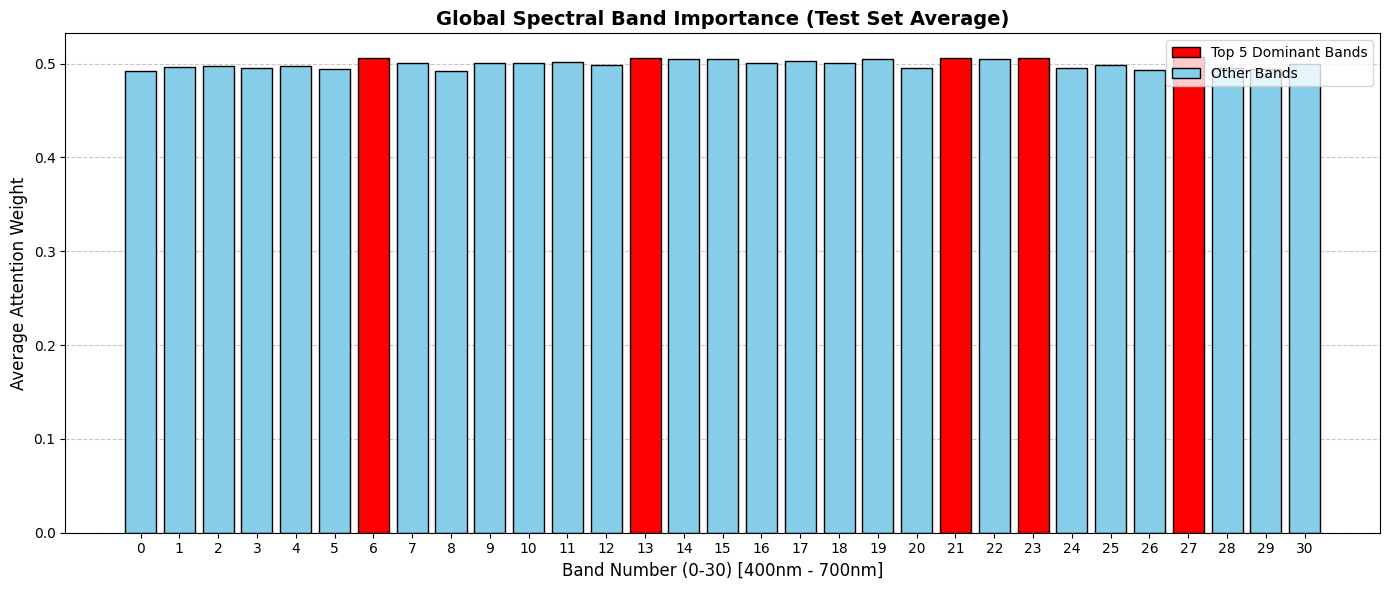

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Ensure model is in evaluation mode
model.eval()

total_images = 0
global_band_weights = np.zeros(31)

print("Extracting spectral weights across the entire Test Set. Please wait...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        b, c, _, _ = inputs.size()
        
        # 1. Extract the raw channel weights directly from the attention module
        avg_pool_out = model.spectral_attention.avg_pool(inputs).view(b, c)
        batch_weights = model.spectral_attention.fc(avg_pool_out).view(b, c).cpu().numpy()
        
        # 2. Accumulate the weights across the batch
        global_band_weights += np.sum(batch_weights, axis=0)
        total_images += b

# 3. Calculate the global average weight for each band
avg_band_weights = global_band_weights / total_images

# 4. Rank the bands from highest weight to lowest
ranked_indices = np.argsort(avg_band_weights)[::-1]
top_5_bands = ranked_indices[:5]

print(f"\nSuccessfully analyzed {total_images} images.")
print("\n" + "="*50)
print(" 🏆 TOP 5 MOST IMPORTANT SPECTRAL BANDS (GLOBAL) ")
print("="*50)

# Print the top 5 with their calculated wavelengths
for i in range(5):
    band_idx = ranked_indices[i]
    weight = avg_band_weights[band_idx]
    # Mapping Band 0 -> 400nm, Band 30 -> 700nm (10nm steps)
    wavelength = 400 + (band_idx * 10) 
    print(f"Rank {i+1}: Band {band_idx:02d} (~{wavelength}nm) | Average Weight: {weight:.4f}")

# ==========================================
# 5. PLOT THE GLOBAL CONSENSUS
# ==========================================
plt.figure(figsize=(14, 6))

# Plot all bands
bars = plt.bar(range(31), avg_band_weights, color='skyblue', edgecolor='black', zorder=2)

# Highlight the Top 5 bands in red
for top_band in top_5_bands:
    bars[top_band].set_color('red')
    bars[top_band].set_edgecolor('black')

plt.title('Global Spectral Band Importance (Test Set Average)', fontsize=14, fontweight='bold')
plt.xlabel('Band Number (0-30) [400nm - 700nm]', fontsize=12)
plt.ylabel('Average Attention Weight', fontsize=12)
plt.xticks(range(31))
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)

# Custom legend
legend_elements = [
    Patch(facecolor='red', edgecolor='black', label='Top 5 Dominant Bands'),
    Patch(facecolor='skyblue', edgecolor='black', label='Other Bands')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("global_top_bands_test_set.png", dpi=300)
plt.show()

In [12]:
import json
import numpy as np

HISTORY_SAVE_PATH = "training_hsi_history.json"

try:
    # Load the tracked history
    with open(HISTORY_SAVE_PATH, 'r') as f:
        history = json.load(f)

    # Find the index of the absolute lowest validation loss
    best_epoch_idx = np.argmin(history['val_loss'])

    # Extract the corresponding stats for that epoch
    best_val_loss = history['val_loss'][best_epoch_idx]
    best_val_acc = history['val_accuracy'][best_epoch_idx]
    best_train_loss = history['loss'][best_epoch_idx]
    best_train_acc = history['accuracy'][best_epoch_idx]

    # Print it out nicely
    print("\n" + "="*50)
    print(f" 🏆 BEST MODEL STATS (Saved at Epoch {best_epoch_idx + 1}) 🏆")
    print("="*50)
    print(f" Training Loss:       {best_train_loss:.4f}")
    print(f" Training Accuracy:   {best_train_acc:.4f}")
    print(f" Validation Loss:     {best_val_loss:.4f}")
    print(f" Validation Accuracy: {best_val_acc:.4f}")
    print("="*50 + "\n")

except FileNotFoundError:
    print(f"Error: Could not find '{HISTORY_SAVE_PATH}'. Make sure you are running this in the same directory where your model was trained!")


 🏆 BEST MODEL STATS (Saved at Epoch 88) 🏆
 Training Loss:       0.2920
 Training Accuracy:   0.8966
 Validation Loss:     0.2639
 Validation Accuracy: 0.9022

